# Loan Default Prediction — Exploratory Data Analysis

This notebook explores the Loan Default Prediction dataset (Kaggle, nikhil1e9; ~255K rows, 18 columns) to understand feature distributions, identify data quality issues, and statistically validate which features are associated with loan default before building predictive models in 02_preprocessing.ipynb and 03_modeling.ipynb.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/Loan_default.csv')
print(df.shape)
df.head()

(255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [3]:
df['Default'].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

## Target Variable

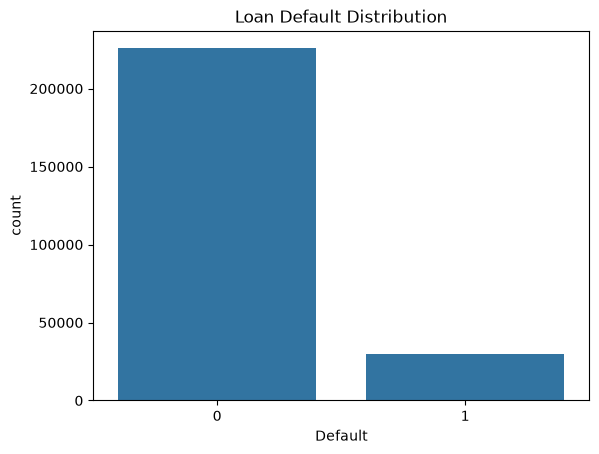

In [4]:
sns.countplot(x='Default',data=df)
plt.title('Loan Default Distribution')
plt.show()

The target variable is heavily imbalanced: **88.4% of loans did not default** (class 0)
and **11.6% defaulted** (class 1). This imbalance is expected in real-world lending data.
Accuracy alone will be a misleading evaluation metric.A model that always predicts
"no default" would score 88.4% accuracy while being completely useless. This will be
handled during modeling using class weighting, and evaluation will be based on ROC-AUC
and Precision-Recall metrics instead.

## Numeric Features

In [5]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove('Default') #exclude the target itself from "features"
print(numeric_cols)

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']


In [6]:
df[numeric_cols].describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000


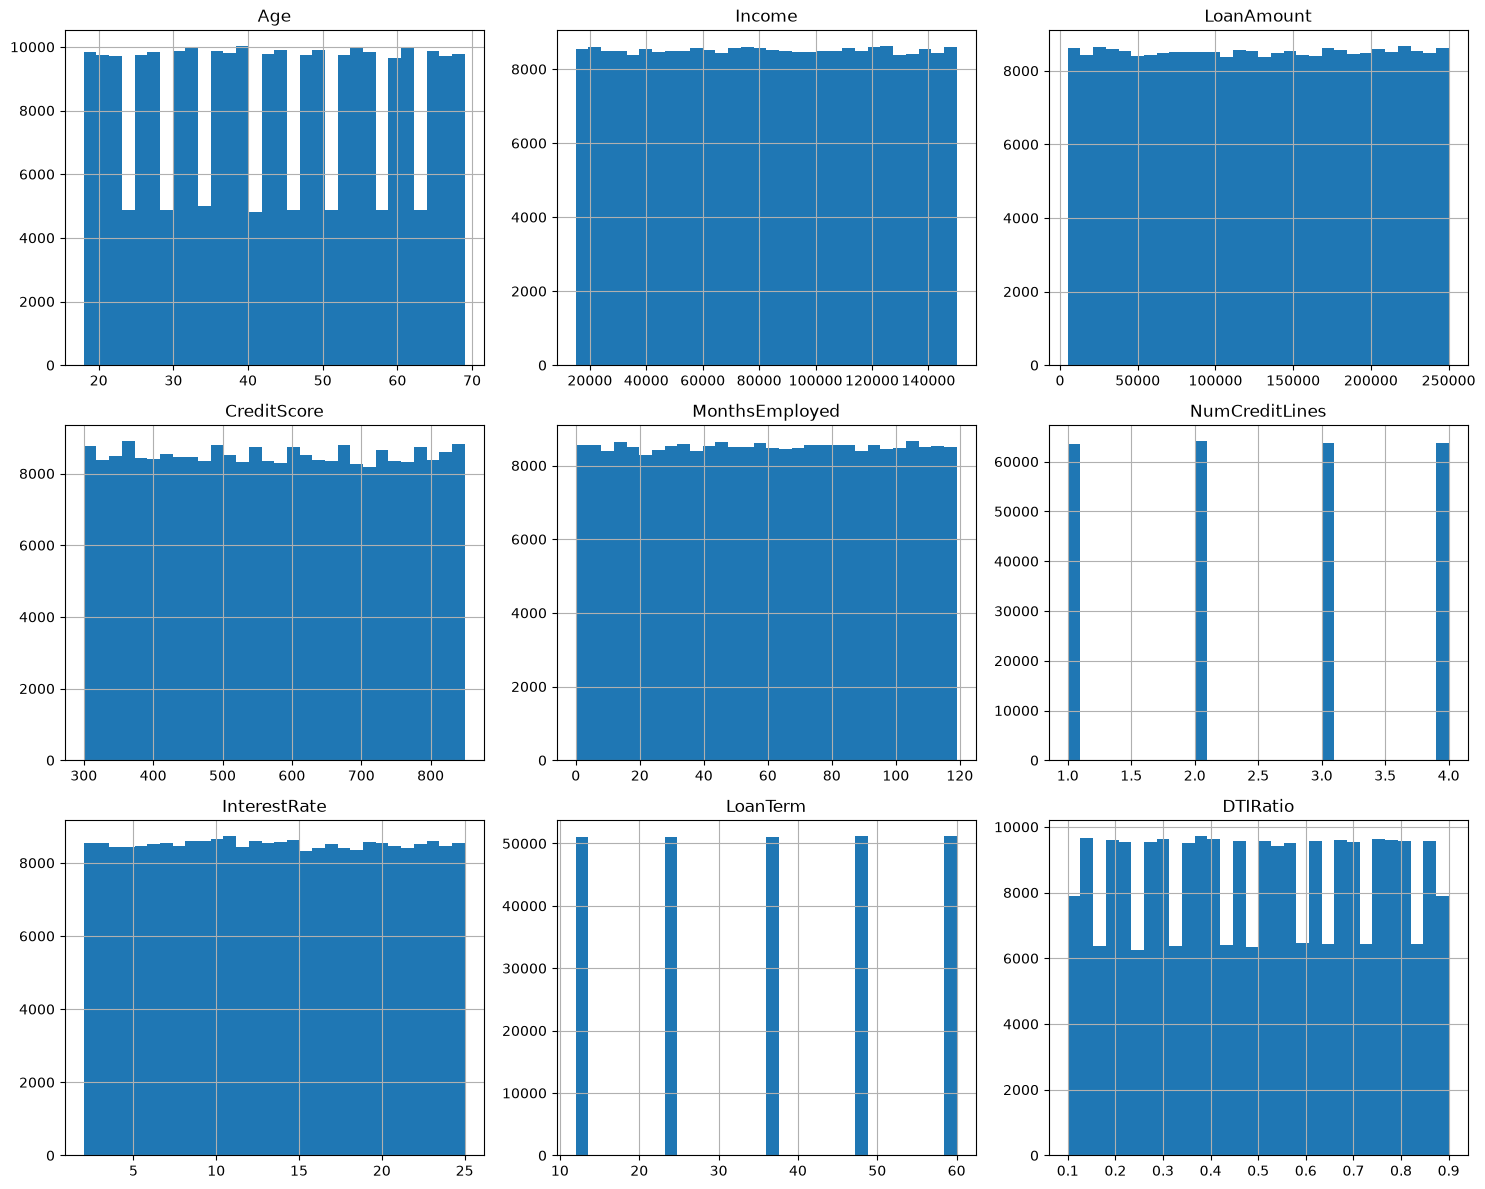

In [7]:
df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.tight_layout()
plt.show()

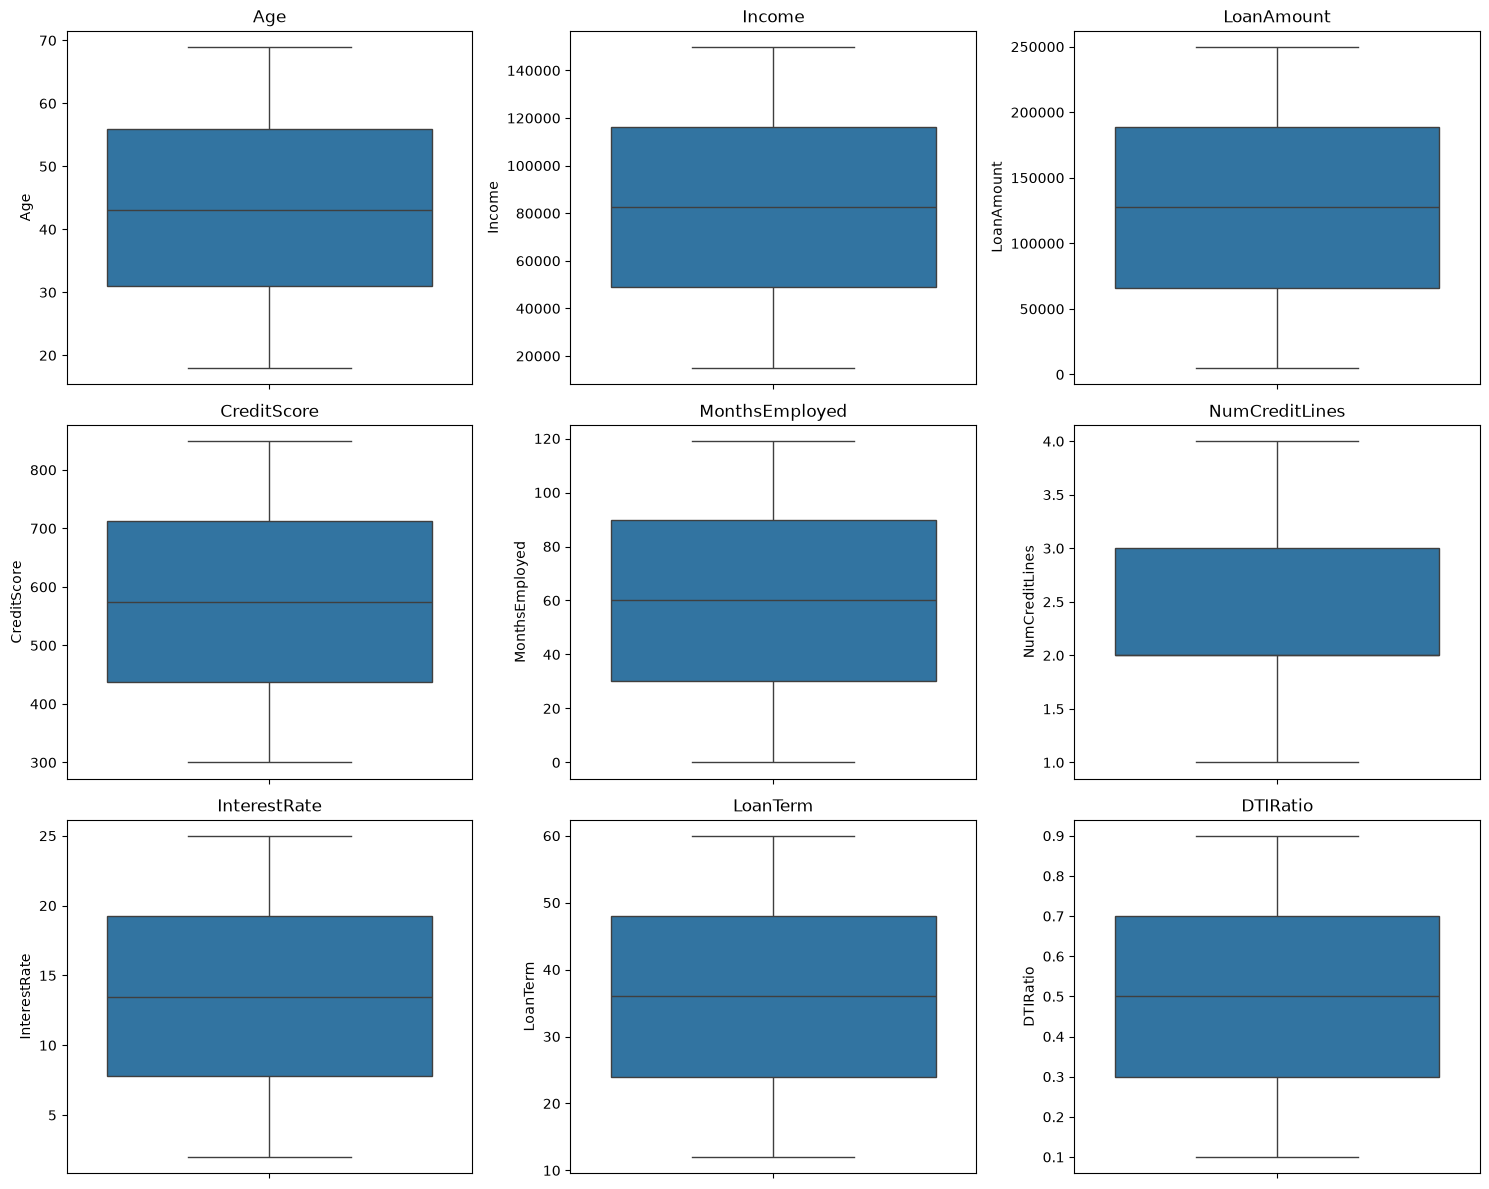

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Outlier Assessment

Although boxplots provide a visual indication of potential outliers, we also quantify them using the 1.5 × IQR rule. This helps determine whether extreme values are present in sufficient numbers to influence subsequent analyses such as correlation estimation.

In [9]:
numeric_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": n_outliers,
        "Percent": round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values("Percent", ascending=False)

,Feature,Outliers,Percent
0,Age,0,0.0
1,Income,0,0.0
2,LoanAmount,0,0.0
3,CreditScore,0,0.0
4,MonthsEmployed,0,0.0
5,NumCreditLines,0,0.0
6,InterestRate,0,0.0
7,LoanTerm,0,0.0
8,DTIRatio,0,0.0


No meaningful outliers were detected according to the 1.5 × IQR criterion. Therefore Pearson correlation is appropriate for assessing linear relationships among numeric variables

## Key Observations from Numeric Feature Distributions

### Distribution Shape
Most of the numeric features appear to be fairly evenly distributed across their respective ranges, with no strong evidence of skewness. This is also reflected in the summary statistics, where the mean and median are very close for each variable (for example, **Age**: mean = 43.5, median = 43; **Income**: mean = 82,499, median = 82,466). This suggests that the distributions are reasonably balanced.

### Outliers
The boxplots do not show any observations outside the whiskers, indicating that there are no noticeable outliers in the numeric features. Since no extreme values are present, there is no need to apply outlier treatment such as capping or removing observations before modeling.

### Feature Characteristics
Two variables—**NumCreditLines** and **LoanTerm**—take only a limited number of ordered integer values. **NumCreditLines** ranges from 1 to 4, while **LoanTerm** is recorded as one of five possible values (12, 24, 36, 48, or 60 months). Although these variables are technically discrete, they are treated as continuous numeric features in the subsequent statistical analysis and modeling. Given their ordered nature and the large sample size, this is a reasonable simplification.

## Categorical Features

In [10]:
categorical_cols = df.select_dtypes(include=['object','str']).columns.tolist()
print(categorical_cols)
print(df['LoanID'].nunique() == len(df))   # should print True
categorical_cols.remove('LoanID')

['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
True


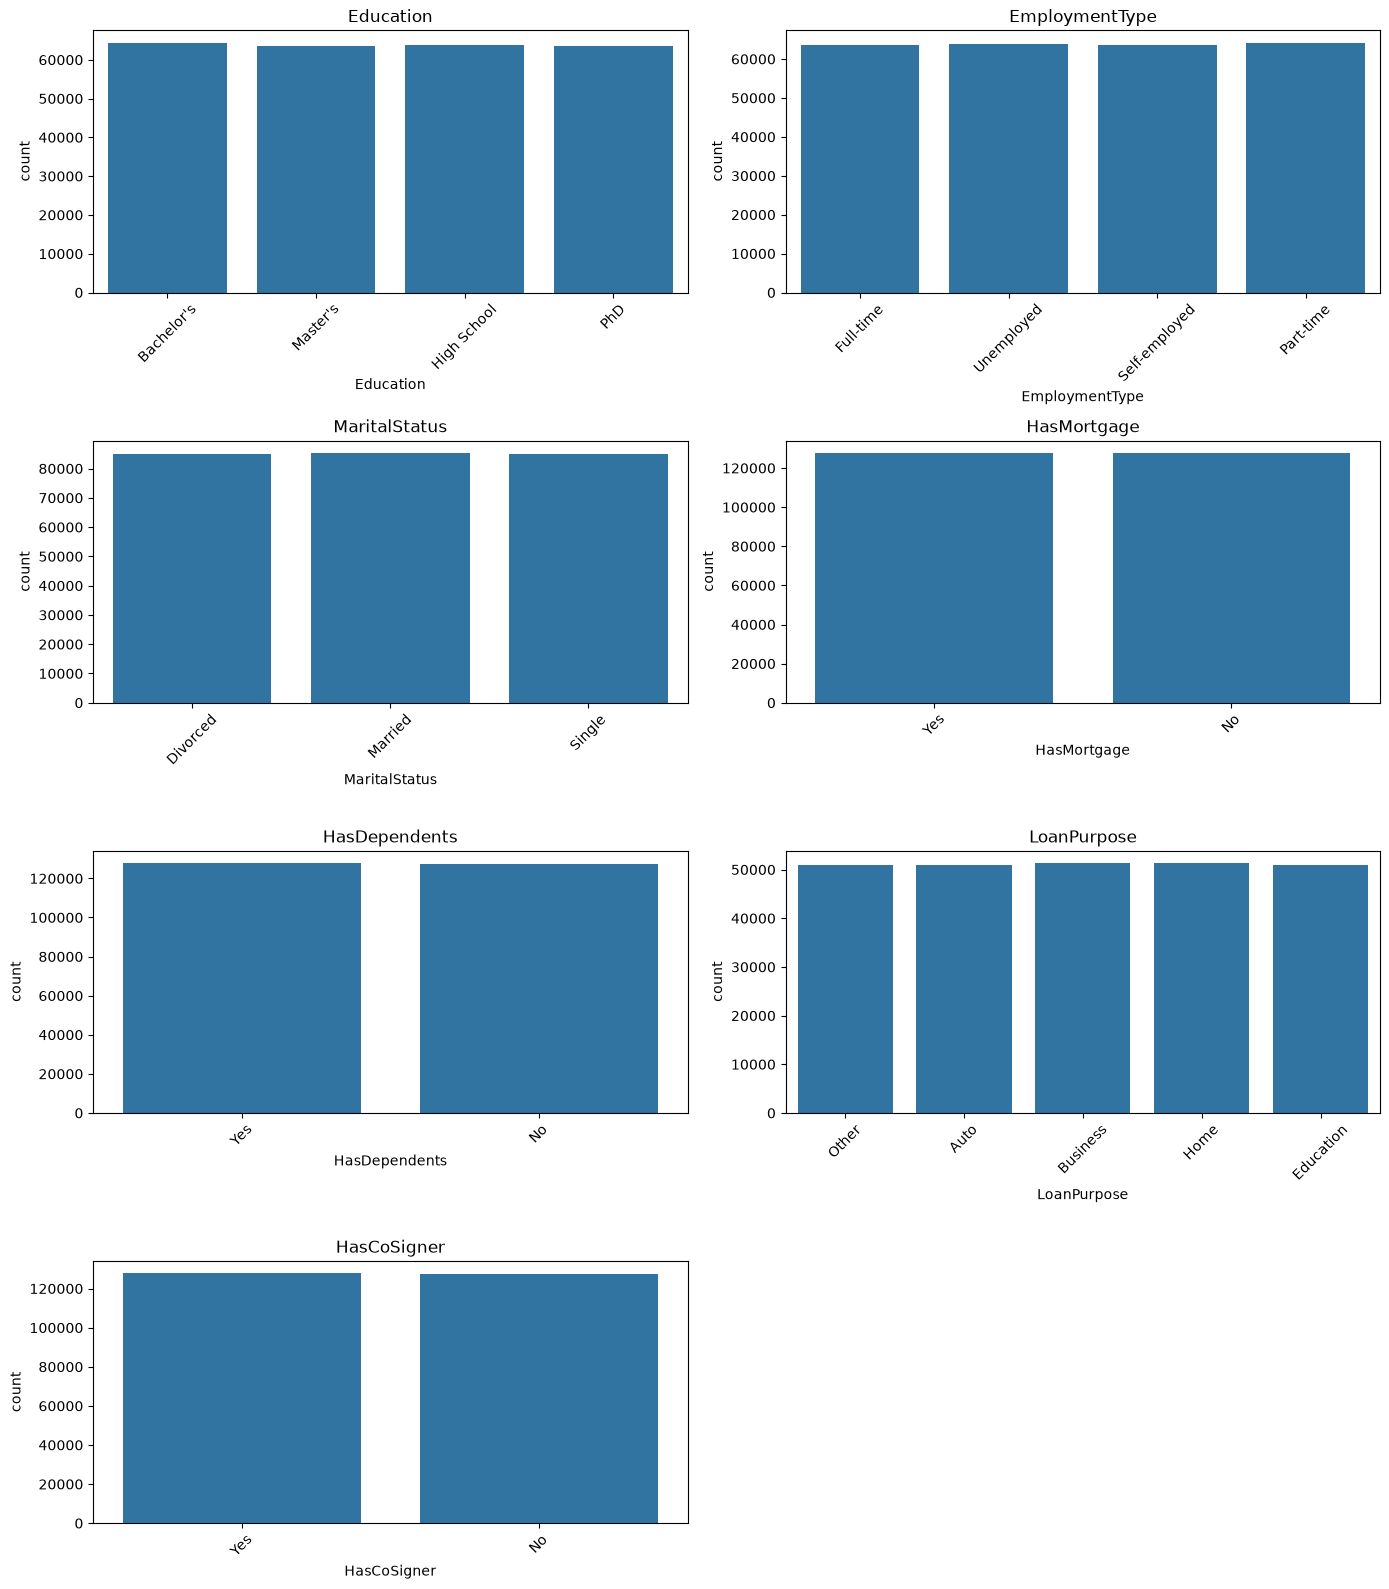

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
# remove any leftover empty subplot slots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

All categorical features are near-perfectly balanced across their categories. Each
category within Education, EmploymentType, MaritalStatus, and LoanPurpose contains
roughly equal numbers of observations. The binary columns (HasMortgage, HasDependents,
HasCoSigner) show an approximate 50/50 split. This further supports the conclusion that
this is a synthetically generated dataset. No rare categories exist, so no category
collapsing or grouping is needed before modeling.

## Data Quality Checks

In [12]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

### Since no missing values exist, no imputation strategy is required, eliminating the risk of introducing imputation bias.

In [13]:
print(df.duplicated().sum())

0


### No duplicate observations here

## Bivariate Analysis and Statistical Testing

Here we examine how each feature
relates to the target variable (Default), first visually and then through formal
hypothesis tests.

In [14]:
from scipy.stats import chi2_contingency, ttest_ind

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('Default')

categorical_cols = df.select_dtypes(include=['object','str']).columns.tolist()
categorical_cols.remove('LoanID')

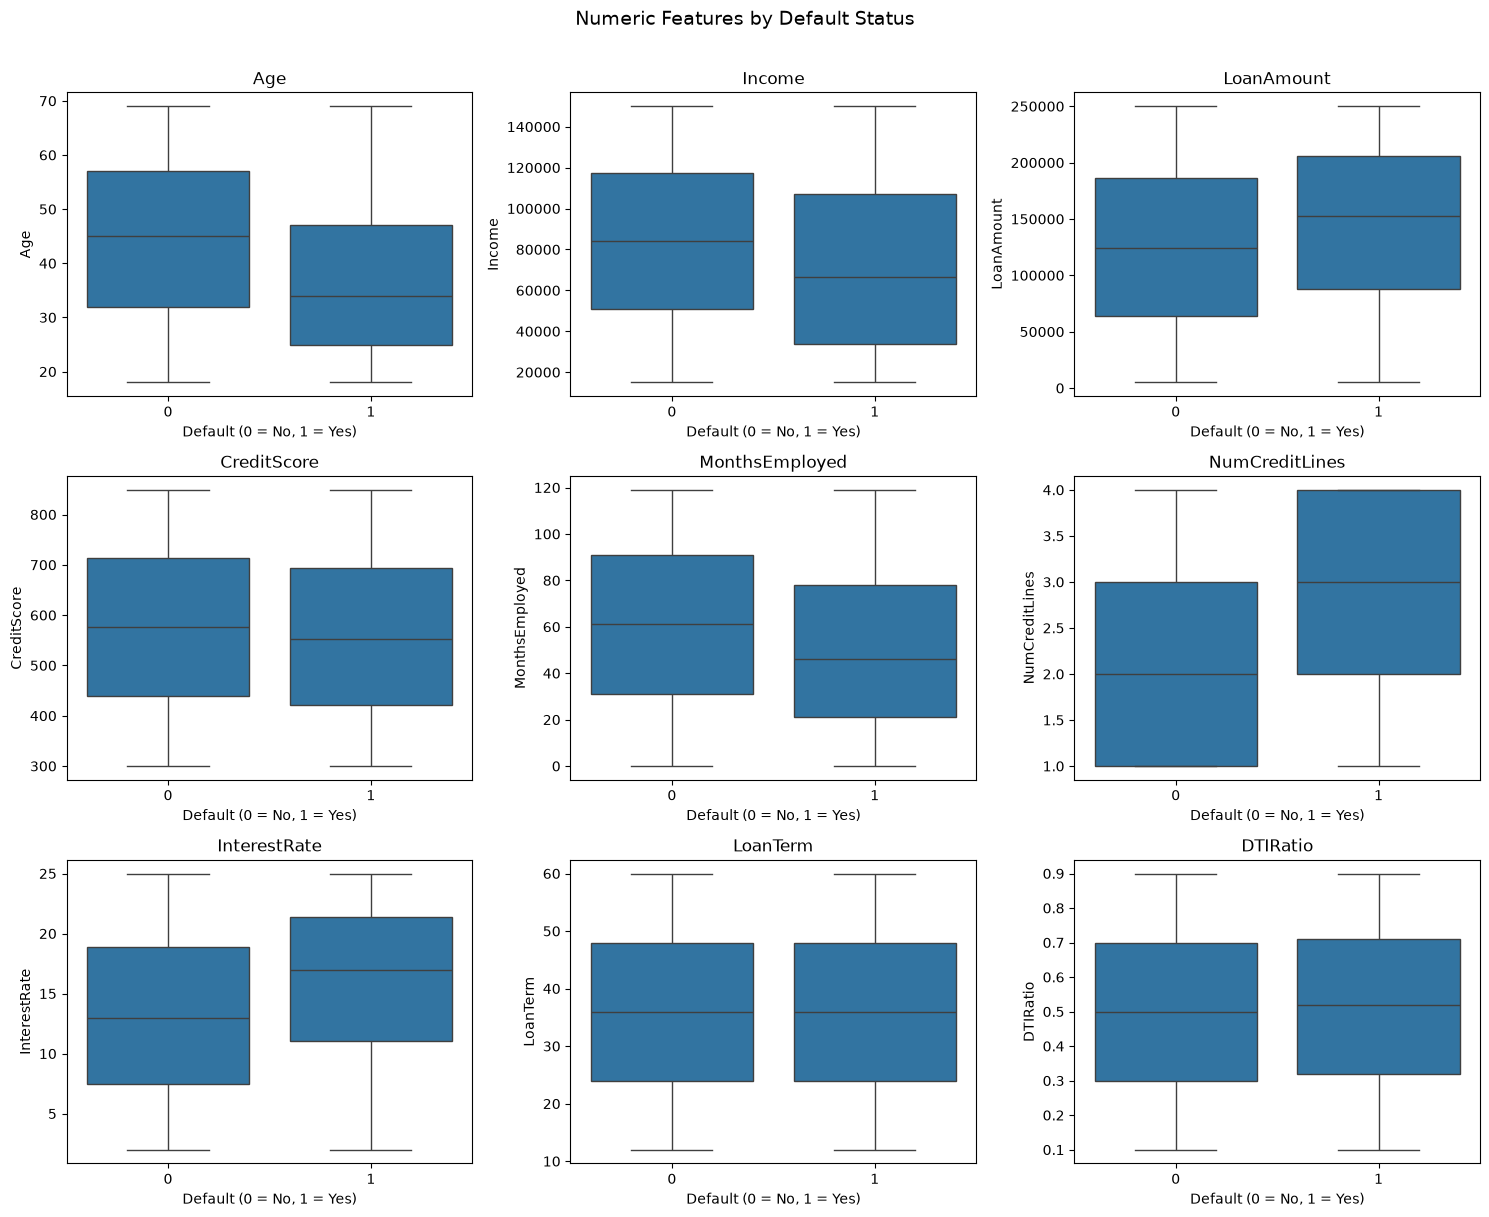

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Default', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Default (0 = No, 1 = Yes)')

plt.suptitle('Numeric Features by Default Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Observations from the Bivariate Boxplots

The boxplots comparing defaulters (1) and non-defaulters (0) reveal several clear 
patterns, which will be formally confirmed by Welch's independent samples t-tests 
in the next section.
- **Interest Rate:** Defaulters generally have much higher interest rates, making this the most clearly separated feature between the two groups.
- **Age:** Borrowers who defaulted tend to be younger, while non-defaulters are generally older.
- **Income:** Non-defaulters usually have higher incomes, suggesting that lower-income borrowers are more likely to default.
- **Loan Amount:** Defaulters tend to borrow larger loan amounts on average.
- **Months Employed:** Non-defaulters typically have a longer employment history, indicating that stable employment is associated with lower default risk.
- **DTI Ratio:** Defaulters have higher debt-to-income (DTI) ratios, showing that borrowers with a larger debt burden relative to their income are more likely to default.
- **Loan Term:** Both groups have almost identical distributions, indicating that loan term has little to no relationship with default. This will be confirmed by the t-test in the next section.

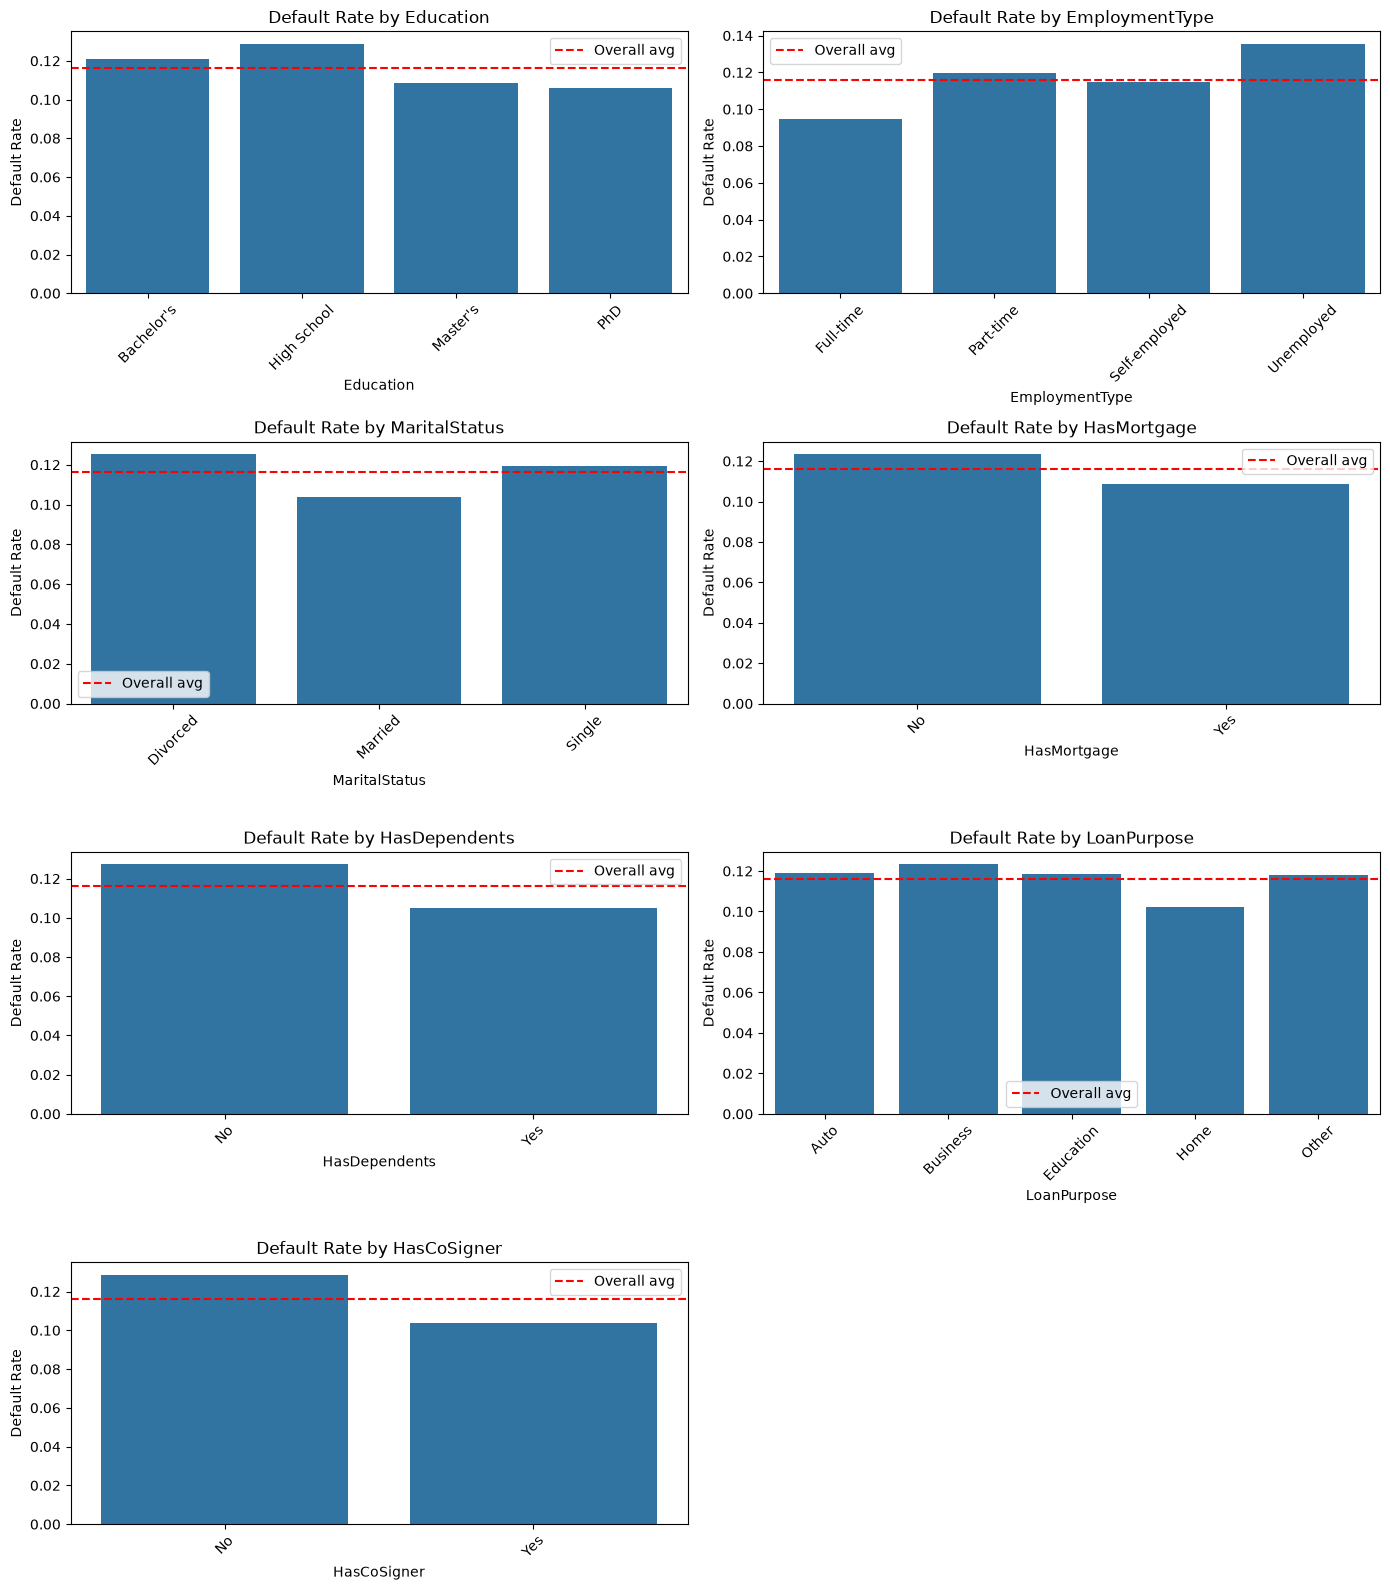

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    default_rate = df.groupby(col)['Default'].mean().reset_index()
    default_rate.columns = [col, 'DefaultRate']
    sns.barplot(x=col, y='DefaultRate', data=default_rate, ax=axes[i])
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=df['Default'].mean(), color='red',
                    linestyle='--', label='Overall avg')
    axes[i].legend()

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Observations from Categorical Default Rates

The red dashed line marks the overall default rate (11.6%). Key patterns:

- **EmploymentType:** Full-time employees show the lowest
  default rate while Part-time and Unemployed borrowers default at higher rates. This is the most striking pattern
- **HasDependents:** Borrowers without dependents show a noticeably higher default rate
  than those with dependents
- **HasCoSigner:** Loans without a co-signer default at a higher rate (a co-signer
  provides additional repayment security)
- **MaritalStatus, Education, HasMortgage, LoanPurpose:** Show smaller but statistically
  significant differences across categories, confirmed by chi-square tests

### Correlation Analysis

To examine linear relationships among numerical features, Pearson correlation is used.

The decision to use Pearson correlation is based on the following observations:

- Boxplots and the 1.5 × IQR rule indicate that no numerical feature contains outliers.
- The numerical variables exhibit well-behaved distributions without severe skewness or extreme values.
- Pearson correlation is appropriate for measuring linear associations between continuous numerical variables under these conditions.

The resulting correlation matrix is used to identify highly correlated predictors that may indicate multicollinearity before model development.

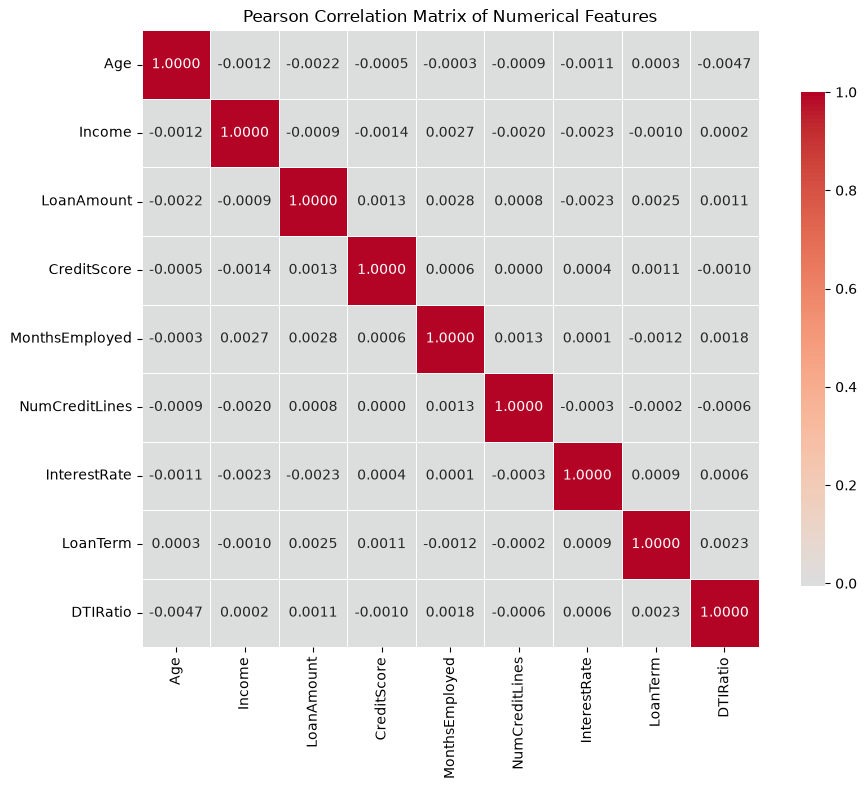

In [17]:
numeric_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

corr_matrix = df[numeric_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".4f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Pearson Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Key Observations from Correlation Analysis

Pearson correlation analysis was performed to examine linear relationships among the numerical predictor variables. Pearson correlation was selected because no numerical feature exhibited outliers based on the 1.5 × IQR criterion, making it an appropriate measure of linear association.

The correlation matrix indicates that all pairwise correlation coefficients are extremely close to zero (|r| < 0.01), suggesting negligible linear relationships between the numerical features.

**Key findings:**

- No pair of numerical features exhibits a meaningful linear correlation.
- The absence of strong pairwise correlations indicates that multicollinearity is unlikely to be a concern during model development.
- Since the numerical predictors appear to contain largely independent information, all numerical variables are retained for subsequent preprocessing and modelling.

### Variance Inflation Factor (VIF)

While pairwise Pearson correlation measures the linear association between two variables at a time, Variance Inflation Factor (VIF) quantifies how well each predictor can be explained by all remaining predictors collectively.

VIF is computed to assess multicollinearity prior to model development, particularly because Logistic Regression is sensitive to highly correlated predictors.

A commonly used interpretation is:

- **VIF = 1** : No multicollinearity
- **1 < VIF < 5** : Low to moderate multicollinearity (generally acceptable)
- **VIF ≥ 5** : Potential multicollinearity concern
- **VIF ≥ 10** : Severe multicollinearity

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

numeric_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

X = df[numeric_cols]

# Add intercept
X_const = add_constant(X)

vif_df = pd.DataFrame({
    "Feature": X_const.columns,
    "VIF": [
        variance_inflation_factor(X_const.values, i)
        for i in range(X_const.shape[1])
    ]
})

# Remove the intercept row
vif_df = (
    vif_df[vif_df["Feature"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_df

,Feature,VIF
0,DTIRatio,1.000033
1,Age,1.000031
2,LoanAmount,1.000029
3,Income,1.000022
4,MonthsEmployed,1.000022
5,LoanTerm,1.000016
6,InterestRate,1.000013
7,NumCreditLines,1.000008
8,CreditScore,1.000007


### Key Observations from Variance Inflation Factor (VIF) Analysis

Variance Inflation Factor (VIF) was computed to further assess multicollinearity among the numerical predictor variables.

All numerical features exhibit VIF values extremely close to **1.0**, indicating that each predictor provides unique information and cannot be meaningfully explained by the remaining predictors.

**Key findings:**

- All numerical predictors have VIF values approximately equal to **1**, indicating an absence of multicollinearity.
- The VIF results are consistent with the Pearson correlation analysis, which also showed negligible pairwise linear relationships among the numerical features.
- Since multicollinearity is not a concern, all numerical predictors are retained for subsequent preprocessing and model development.

### Assessment of Variance Homogeneity

Before selecting the appropriate hypothesis test, Levene's test is performed to evaluate whether the numerical features have equal variances across the two loan default groups.

In [19]:
from scipy.stats import levene
import pandas as pd

numeric_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

group0 = df[df['Default'] == 0]
group1 = df[df['Default'] == 1]

levene_results = []

for col in numeric_cols:
    stat, p = levene(group0[col], group1[col])

    levene_results.append({
        "Feature": col,
        "Levene Statistic": stat,
        "p-value": p,
        "Equal Variance": "Yes" if p > 0.05 else "No"
    })

levene_df = pd.DataFrame(levene_results)

levene_df

,Feature,Levene Statistic,p-value,Equal Variance
0,Age,819.269730,6.730089e-180,No
1,Income,329.257665,1.551694e-73,No
2,LoanAmount,52.382230,4.581144e-13,No
3,CreditScore,1.310808,2.522495e-01,Yes
4,MonthsEmployed,76.992566,1.726272e-18,No
5,NumCreditLines,32.045632,1.507542e-08,No
6,InterestRate,334.333021,1.221347e-74,No
7,LoanTerm,0.311896,5.765193e-01,Yes
8,DTIRatio,9.018365,2.673063e-03,No


### Interpretation

Levene's test indicates that the equal variance assumption is violated for most numerical features (p < 0.05). Therefore, Welch's independent samples t-test, which does not require equal variances, is used in the subsequent hypothesis testing.

## Formal Statistical Testing

Following the exploratory data analysis and assessment of statistical assumptions, formal hypothesis tests are conducted to determine whether individual features are significantly associated with loan default status.

The choice of statistical test is based on the type of variable and the assumptions evaluated in the previous section.

- **Categorical features → Chi-square Test of Independence**

    **H₀:** The categorical feature and Default are independent (no association).

    **H₁:** The categorical feature and Default are associated.

- **Numerical features → Welch's Independent Samples t-test**

    Welch's t-test is selected because Levene's test indicated unequal variances for most numerical features. Unlike the classical Student's t-test, Welch's t-test does not assume equal population variances while remaining appropriate for large independent samples.

    **H₀:** The mean value is equal for defaulters and non-defaulters.

    **H₁:** The mean value differs between the two groups.

**Significance level:** α = 0.05

In [20]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# Function to interpret Cramer's V
def interpret_cramers_v(v):
    if v < 0.10:
        return "Negligible"
    elif v < 0.30:
        return "Weak"
    elif v < 0.50:
        return "Moderate"
    else:
        return "Strong"

chi2_results = []

for col in categorical_cols:
    # Contingency table
    contingency_table = pd.crosstab(df[col], df["Default"])

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Cramer's V
    n = contingency_table.to_numpy().sum()
    r, c = contingency_table.shape
    cramers_v = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

    chi2_results.append({
        "Feature": col,
        "Chi2 Statistic": round(chi2, 2),
        "p-value": f"{p:.3e}",
        "Significant": "Yes" if p < 0.05 else "No",
        "Cramer's V": round(cramers_v, 3),
        "Association Strength": interpret_cramers_v(cramers_v)
    })

chi2_df = (
    pd.DataFrame(chi2_results)
    .sort_values("Chi2 Statistic", ascending=False)
    .reset_index(drop=True)
)

chi2_df

,Feature,Chi2 Statistic,p-value,Significant,Cramer's V,Association Strength
0,EmploymentType,529.74,1.707e-114,Yes,0.046,Negligible
1,HasCoSigner,390.31,7.103e-87,Yes,0.039,Negligible
2,HasDependents,306.85,1.060e-68,Yes,0.035,Negligible
3,Education,214.02,3.940e-46,Yes,0.029,Negligible
4,MaritalStatus,200.36,3.106e-44,Yes,0.028,Negligible
5,HasMortgage,133.25,7.963e-31,Yes,0.023,Negligible
6,LoanPurpose,127.93,1.077e-26,Yes,0.022,Negligible


### Key Observations

All categorical features are statistically significantly associated with loan default (Chi-square test, p < 0.05).

However, all Cramer's V values are below 0.10, indicating **negligible practical association** between each categorical feature and the target variable when considered individually.

This pattern is expected because the dataset contains over 255,000 observations. With such a large sample, even very small differences can produce highly significant p-values. Therefore, Cramer's V provides a more meaningful assessment of practical significance than the p-value alone.

Although these categorical variables exhibit only negligible individual associations with loan default, they are retained because multiple weak predictors can collectively improve predictive performance in machine learning models.

In [21]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

# Function to interpret Cohen's d
def interpret_cohens_d(d):
    d = abs(d)
    if d < 0.20:
        return "Negligible"
    elif d < 0.50:
        return "Small"
    elif d < 0.80:
        return "Medium"
    else:
        return "Large"

ttest_results = []

group0 = df[df["Default"] == 0]   # Non-defaulters
group1 = df[df["Default"] == 1]   # Defaulters

for col in numeric_cols:

    # Welch's Independent Samples t-test
    t_stat, p = ttest_ind(
        group0[col],
        group1[col],
        equal_var=False
    )

    # Cohen's d
    n1 = len(group0[col])
    n2 = len(group1[col])

    s1 = group0[col].std(ddof=1)
    s2 = group1[col].std(ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) /
        (n1 + n2 - 2)
    )

    cohens_d = (group0[col].mean() - group1[col].mean()) / pooled_sd

    ttest_results.append({
        "Feature": col,
        "Welch's t Statistic": round(t_stat, 2),
        "p-value": f"{p:.3e}",
        "Significant": "Yes" if p < 0.05 else "No",
        "Cohen's d": round(cohens_d, 3),
        "Effect Size": interpret_cohens_d(cohens_d)
    })

ttest_df = pd.DataFrame(ttest_results)

# Sort by absolute effect size
ttest_df["Absolute d"] = ttest_df["Cohen's d"].abs()

ttest_df = (
    ttest_df
    .sort_values("Absolute d", ascending=False)
    .drop(columns="Absolute d")
    .reset_index(drop=True)
)

ttest_df

,Feature,Welch's t Statistic,p-value,Significant,Cohen's d,Effect Size
0,Age,90.68,0.000e+00,Yes,0.531,Medium
1,InterestRate,-69.27,0.000e+00,Yes,-0.413,Small
2,Income,48.15,0.000e+00,Yes,0.311,Small
3,MonthsEmployed,50.19,0.000e+00,Yes,0.305,Small
4,LoanAmount,-44.52,0.000e+00,Yes,-0.272,Small
5,CreditScore,17.30,8.157e-67,Yes,0.107,Negligible
6,NumCreditLines,-14.30,2.789e-46,Yes,-0.088,Negligible
7,DTIRatio,-9.79,1.387e-22,Yes,-0.060,Negligible
8,LoanTerm,-0.27,7.834e-01,No,-0.002,Negligible


### Key Observations

Welch's independent samples t-test indicates that 8 of the 9 numerical features differ significantly between defaulters and non-defaulters (p < 0.05). LoanTerm is the only feature that does not exhibit a statistically significant difference.

Effect size analysis using Cohen's d provides additional practical insight. Age exhibits a **medium** effect size, InterestRate, Income, MonthsEmployed and LoanAmount show **small** effects, while the remaining numerical features have **negligible** effect sizes.

These findings illustrate that statistical significance does not necessarily imply a large practical effect, particularly in very large datasets.

In [22]:
chi2_df = pd.DataFrame(chi2_results)[['Feature', 'p-value', 'Significant']]
chi2_df['Test'] = 'Chi-square'

ttest_df = pd.DataFrame(ttest_results)[['Feature', 'p-value', 'Significant']]
ttest_df["Test"] = "Welch's t-test"

summary = pd.concat([chi2_df, ttest_df], ignore_index=True)
summary['p-value'] = summary['p-value'].astype(float)          # cast back to numeric
summary = summary.sort_values('p-value').reset_index(drop=True)
summary['p-value'] = summary['p-value'].apply(lambda x: f"{x:.3e}")  # re-format for display
print(summary.to_string(index=False))


       Feature    p-value Significant           Test
           Age  0.000e+00         Yes Welch's t-test
MonthsEmployed  0.000e+00         Yes Welch's t-test
    LoanAmount  0.000e+00         Yes Welch's t-test
        Income  0.000e+00         Yes Welch's t-test
  InterestRate  0.000e+00         Yes Welch's t-test
EmploymentType 1.707e-114         Yes     Chi-square
   HasCoSigner  7.103e-87         Yes     Chi-square
 HasDependents  1.060e-68         Yes     Chi-square
   CreditScore  8.157e-67         Yes Welch's t-test
NumCreditLines  2.789e-46         Yes Welch's t-test
     Education  3.940e-46         Yes     Chi-square
 MaritalStatus  3.106e-44         Yes     Chi-square
   HasMortgage  7.963e-31         Yes     Chi-square
   LoanPurpose  1.077e-26         Yes     Chi-square
      DTIRatio  1.387e-22         Yes Welch's t-test
      LoanTerm  7.834e-01          No Welch's t-test


### Key Findings from Statistical Testing

**All 7 categorical features** show a statistically significant association with loan
default (chi-square test, p < 0.0001 for all).

**8 out of 9 numeric features** show statistically significant differences in mean
values between defaulters and non-defaulters (t-test, p < 0.0001).

**Exception - LoanTerm (p = 0.78):** The t-test finds no significant difference in
loan term between defaulters and non-defaulters. This feature will be excluded from
the model to avoid adding noise with no predictive value.

Note the gap between statistical and practical significance: despite p<0.0001 almost everywhere, Cramer's V is Negligible for all 7 categorical features, and Cohen's d is Small or Negligible for 7 of 9 numeric features (Age is the lone Medium effect). With n=255,347, even trivial differences reach significance — effect size, not the p-value, is what should drive feature-importance intuition here

---
## EDA Summary — Decisions Feeding into Preprocessing

| Decision | Basis |
|---|---|
| Drop `LoanID` | Unique identifier, no predictive value |
| Drop `LoanTerm` | t-test p = 0.78, no significant association with default |
| Encode all 7 categorical features | Chi-square showed statistically significant associations with Default; all variables are retained despite negligible individual effect sizes. |
| Retain all remaining 8 numeric features | Welch's t-test found significant mean differences for all except LoanTerm; most effect sizes are Small or Negligible, but the features may still provide complementary predictive information. |
| No outlier treatment needed | Boxplots showed no outliers in any numeric column |
| No missing value imputation needed | Zero nulls across all 18 columns |
| Address class imbalance via class weighting | Target split: 88.4% / 11.6% |
| Evaluation metric: ROC-AUC, not accuracy | Imbalanced target makes accuracy misleading |

These decisions will be implemented directly in `02_preprocessing.ipynb`.